# GoalLab Stage 09: Fine-tune a language model to judge source eligibility

Created by Shivam Bharadwaj · [Course home](../../../README.md) · [Stage map](../STAGES.md)

[Stage 08](08_one_problem_many_algorithms.ipynb) · [Stage 10](10_verifiable_reasoning_grpo.ipynb)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshivambharadwaj/Reinforcement-Learning-Course/blob/main/projects/goallab/notebooks/09_small_model_sft_dpo.ipynb)

**Build:** fine-tune SmolLM2-135M to decide whether an observed GoalLab source is eligible for a briefing. This is real pretrained language-model SFT followed by DPO.

**Run:** use the full repository, install `requirements.txt` (Stage 09 also uses `requirements-modern.txt`), then restart the kernel and run all cells. Every stage reconstructs its inputs from shared GoalLab modules; earlier notebook execution is not required. The project progression is cumulative in capabilities, without hidden notebook state.

Code: MIT. Text and plots: CC BY 4.0. Results below are reproduced from the supplied GoalLab cases; the evaluation section explains their scope and failure cases.

**Learn the algorithm first:** [Course Notebook 09](../../../notebooks/09_small_model_sft_dpo.ipynb). Then use this GoalLab stage to apply it to evidence gathering and briefing verification.


In [1]:
import sys, subprocess, platform, tempfile, json
from pathlib import Path
IN_COLAB = 'google.colab' in sys.modules
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'rl_course').is_dir()), Path.cwd())
if IN_COLAB and not (ROOT / 'rl_course').exists():
    ROOT = Path('/content/Reinforcement-Learning-Course')
    if not ROOT.exists():
        subprocess.run(['git', 'clone', '--depth', '1', 'https://github.com/bshivambharadwaj/Reinforcement-Learning-Course.git', str(ROOT)], check=True)
if not (ROOT / 'rl_course' / 'goallab.py').exists():
    raise FileNotFoundError('Use the complete repository revision containing the GoalLab stages.')
sys.path.insert(0, str(ROOT))
import numpy as np, torch, matplotlib.pyplot as plt
from IPython.display import Markdown, display
from rl_course import goallab as goal
from rl_course import goallab_learning as learning
torch.set_num_threads(2)
%matplotlib inline
INK, GOLD, SAGE, PLUM, PAPER = '#292332', '#af824a', '#768165', '#87708c', '#f5f1e8'
plt.rcParams.update({'figure.figsize': (9, 4), 'figure.dpi': 110, 'figure.facecolor': PAPER,
    'axes.facecolor': PAPER, 'text.color': INK, 'axes.labelcolor': INK,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.prop_cycle': plt.cycler(color=[GOLD, SAGE, PLUM, INK]), 'axes.grid': True, 'grid.alpha': .15})
def table(headers, rows):
    display(Markdown('| ' + ' | '.join(headers) + ' |\n|' + '|'.join(['---'] * len(headers)) + '|\n' +
        '\n'.join('| ' + ' | '.join(str(x).replace('|', '&#124;').replace('\n', '<br>') for x in row) + ' |' for row in rows)))
def learning_plot(runs):
    for label, run in runs.items():
        h = run['history']
        plt.plot(h[:, 0], h[:, 1], label=label)
    plt.xlabel('Training environment actions'); plt.ylabel('Exact policy return')
    plt.legend(); plt.tight_layout(); plt.show()
def report_policies(runs):
    table(['Controller', 'Exact return', 'Held-out briefing success', 'Calls/case'],
          [[label, round(run['env'].values(run['policy'])[0][run['env'].start_index], 3),
            f"{learning.heldout(run['policy'])['success']:.1%}", learning.heldout(run['policy'])['calls']]
           for label, run in runs.items()])
workspace = goal.make_workspace(7, 'test')
print(f'{goal.VERSION} | Python {platform.python_version()} | NumPy {np.__version__} | Torch {torch.__version__} | CPU')

GoalLab-v1 | Python 3.12.4 | NumPy 1.26.4 | Torch 2.11.0+cu130 | CPU


## Shared contract

One source is an approved measurement for the requested period. Other sources are drafts or forecasts, deliberately newer and numerically different. Training rows use 0..3; held-out rows use 4..7 and a different period. Authority rules stay the same. `search` reveals IDs and timestamps; `read` reveals content. A valid briefing needs the correct value, period, and citation.

The simulator and models are readable teaching code, not a security boundary. Final `verify()` is outside the policy interface. The first eight stages use a finite two-source abstraction: read twice, choose a citation, then submit or claim completion. Claiming completion produces no briefing. This fixed horizon makes exact comparisons possible; later stages vary investigation budgets.

## Learning objectives and the stage contract

Trace completion masks and token alignment; freeze the SFT reference; connect generated text to actual tool decisions.

**Input:** the shared evidence workspace or the preceding component reconstructed below. **Output:** the capability named in this stage, evaluated against the common briefing contract. Read the worked calculation before running the full experiment; then inspect the implementation and predict the constraint exercise.

## Work it out: align tokens, masks, and next-token predictions

The logit at position t predicts token t+1. A completion mask therefore shifts with the target tokens. Prompt tokens and padding must contribute zero to the completion score, while EOS is counted once.

SFT averages completion loss by token count here; DPO uses summed completion log probabilities. Those objectives have different scales. The code below checks a miniature mask before loading the real model.

In [2]:
# Example: two prompt tokens, two completion tokens, EOS, then padding.
completion_mask=torch.tensor([[0.,0.,1.,1.,1.,0.]])
next_token_logps=torch.tensor([[-9.,-.2,-.3,-.4,-8.]])
score=(next_token_logps*completion_mask[:,1:]).sum(-1)
print('Completion log probability:',score.item())
assert np.isclose(score.item(),-.9)
print('The prompt prediction (-9) and padding prediction (-8) do not enter the score.')

Completion log probability: -0.8999999761581421
The prompt prediction (-9) and padding prediction (-8) do not enter the score.


## Build the component

The central implementation is included here so you can step through and edit the update or tool logic. The shared modules retain the same reference implementation for the integrated project. Inspect shapes, terminal handling, frozen quantities, and the evaluator boundary before training.

In [3]:
if IN_COLAB:
    subprocess.run([sys.executable,'-m','pip','install','-q','-r',str(ROOT/'requirements-modern.txt')],check=True)
from time import perf_counter
from torch import nn
from rl_course.mini_llm import load, pair_scores, generated_answers, make_data
def batch_tokens(tokenizer, examples, key='chosen'):
    sequences, masks = [], []
    for example in examples:
        prompt = tokenizer.encode(example['prompt'], add_special_tokens=False)
        completion = tokenizer.encode(example[key], add_special_tokens=False) + [tokenizer.eos_token_id]
        sequences.append(prompt + completion)
        masks.append([0] * len(prompt) + [1] * len(completion))
    width = max(map(len, sequences))
    ids = torch.full((len(sequences), width), tokenizer.pad_token_id, dtype=torch.long)
    attention = torch.zeros_like(ids)
    completion_mask = torch.zeros_like(ids, dtype=torch.float32)
    for i, (sequence, mask) in enumerate(zip(sequences, masks)):
        ids[i, :len(sequence)] = torch.tensor(sequence)
        attention[i, :len(sequence)] = 1
        completion_mask[i, :len(sequence)] = torch.tensor(mask)
    return ids, attention, completion_mask


def completion_logps(model, batch):
    ids, attention, completion_mask = batch
    logits = model(input_ids=ids, attention_mask=attention).logits[:, :-1]
    token_logps = logits.log_softmax(-1).gather(-1, ids[:, 1:, None]).squeeze(-1)
    # Prediction at index t corresponds to token t+1. Prompt and pad tokens
    # are excluded; EOS is included once. DPO uses sums, not length averages.
    return (token_logps * completion_mask[:, 1:]).sum(-1)


def run_language(seed=7, sft_steps=36, dpo_steps=24, train_examples=None, test_examples=None):
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    model, tokenizer = load()
    train = make_data(['film', 'meal', 'book', 'game']) if train_examples is None else train_examples
    test = make_data(['service', 'music']) if test_examples is None else test_examples
    assert not {x['prompt'] for x in train} & {x['prompt'] for x in test}
    params = [p for p in model.parameters() if p.requires_grad]
    parameter_counts = (sum(p.numel() for p in model.parameters()), sum(p.numel() for p in params))
    rows, examples, losses = [], {}, {'SFT': [], 'DPO': []}
    reference_test = None

    def measure(stage, seconds):
        win, lose = pair_scores(model, tokenizer, test)
        responses = generated_answers(model, tokenizer, test)
        exact = np.mean([response.lower() == item['chosen'].strip() for response, item in zip(responses, test)])
        relative = float((win - lose - reference_test).mean()) if reference_test is not None else None
        rows.append({'stage': stage, 'heldout_pair_accuracy': float((win > lose).float().mean()),
                     'heldout_generation_accuracy': float(exact), 'mean_pair_margin': float((win - lose).mean()),
                     'margin_change_from_SFT': relative, 'training_seconds': seconds})
        examples[stage] = responses
        print(rows[-1], flush=True)

    measure('Pretrained', 0.)
    optimizer = torch.optim.AdamW(params, lr=2e-4, weight_decay=0.)
    started = perf_counter()
    for _ in range(sft_steps):
        selected = [train[i] for i in rng.choice(len(train), 4, replace=False)]
        batch = batch_tokens(tokenizer, selected)
        loss = -(completion_logps(model, batch) / batch[2].sum(1)).mean()
        optimizer.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(params, 1.); optimizer.step()
        losses['SFT'].append(float(loss.detach()))
    sft_seconds = perf_counter() - started
    reference_train = tuple(t.clone() for t in pair_scores(model, tokenizer, train))
    test_win, test_lose = pair_scores(model, tokenizer, test)
    reference_test = test_win - test_lose
    measure('SFT', sft_seconds)
    optimizer = torch.optim.AdamW(params, lr=5e-5, weight_decay=0.)
    started = perf_counter()
    for _ in range(dpo_steps):
        indices = rng.choice(len(train), 4, replace=False)
        selected = [train[i] for i in indices]
        win = completion_logps(model, batch_tokens(tokenizer, selected, 'chosen'))
        lose = completion_logps(model, batch_tokens(tokenizer, selected, 'rejected'))
        ref_margin = reference_train[0][indices] - reference_train[1][indices]
        loss = -nn.functional.logsigmoid(.1 * (win - lose - ref_margin)).mean()
        optimizer.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(params, 1.); optimizer.step()
        losses['DPO'].append(float(loss.detach()))
    measure('DPO', perf_counter() - started)
    assert np.isfinite(losses['SFT']).all() and np.isfinite(losses['DPO']).all()
    assert abs(losses['DPO'][0] - np.log(2)) < 1e-4, 'Policy starts at the SFT reference'
    return {'rows': rows, 'examples': examples, 'losses': losses, 'test': test,
            'parameter_counts': parameter_counts, 'model': model, 'tokenizer': tokenizer}

## 1. A language interface to the same source records

Generated prompts contain source status, kind, period, and rows from `make_workspace`. The answer is `include` or `exclude`. Training and held-out sources have disjoint IDs, periods, and numerical ranges. They share an authority rule and template family; this is not broad language generalization.

First run downloads a pinned public checkpoint, roughly 0.3 GB, and requires several GB of host memory. The last decoder layer and final normalization are trained. Completion-only masks exclude prompt/padding; EOS is included. The fixed SFT reference is cached on preference pairs before DPO.

In [4]:
if IN_COLAB:
    subprocess.run([sys.executable,'-m','pip','install','-q','-r',str(ROOT/'requirements-modern.txt')],check=True)
from rl_course import mini_llm
from rl_course.goallab_preferences import language_data
train,test=language_data('train'),language_data('test')
print('Train/test sources:',len(train),len(test)); print(test[0]['prompt'])
assert not {e['prompt'] for e in train} & {e['prompt'] for e in test}
run=run_language(seed=7,train_examples=train,test_examples=test)
table(['Stage','Pair accuracy','Generated decision accuracy','Margin change from SFT'],
      [[r['stage'],r['heldout_pair_accuracy'],r['heldout_generation_accuracy'],r['margin_change_from_SFT']] for r in run['rows']])

Train/test sources: 32 16
Requested period: 2026-02.
Source test-0-source-0: status=approved, kind=measurement, period=2026-02, rows=[7, 7].
Include only approved measurements for the requested period.
Decision:


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

{'stage': 'Pretrained', 'heldout_pair_accuracy': 0.25, 'heldout_generation_accuracy': 0.0, 'mean_pair_margin': -0.13871634006500244, 'margin_change_from_SFT': None, 'training_seconds': 0.0}


{'stage': 'SFT', 'heldout_pair_accuracy': 1.0, 'heldout_generation_accuracy': 1.0, 'mean_pair_margin': 3.6255667209625244, 'margin_change_from_SFT': 0.0, 'training_seconds': 24.495405951000066}


{'stage': 'DPO', 'heldout_pair_accuracy': 1.0, 'heldout_generation_accuracy': 1.0, 'mean_pair_margin': 5.6235551834106445, 'margin_change_from_SFT': 1.9979883432388306, 'training_seconds': 32.003104756999164}


| Stage | Pair accuracy | Generated decision accuracy | Margin change from SFT |
|---|---|---|---|
| Pretrained | 0.25 | 0.0 | None |
| SFT | 1.0 | 1.0 | 0.0 |
| DPO | 1.0 | 1.0 | 1.9979883432388306 |

## 2. Use generated decisions to produce briefings

Choose the first source whose generated answer is exactly `include`; otherwise abstain. No verifier repairs the model's choices. Report final briefing success separately from pairwise likelihood accuracy. A higher DPO margin need not improve generated actions.

| Case | Generated decisions | Verified briefing |
|---|---|---|
| test-0 | ['include', 'exclude'] | True |
| test-1 | ['exclude', 'include'] | True |
| test-2 | ['include', 'exclude'] | True |
| test-3 | ['exclude', 'include'] | True |
| test-4 | ['include', 'exclude'] | True |
| test-5 | ['include', 'exclude'] | True |
| test-6 | ['exclude', 'include'] | True |
| test-7 | ['exclude', 'include'] | True |

End-to-end success: 1.0


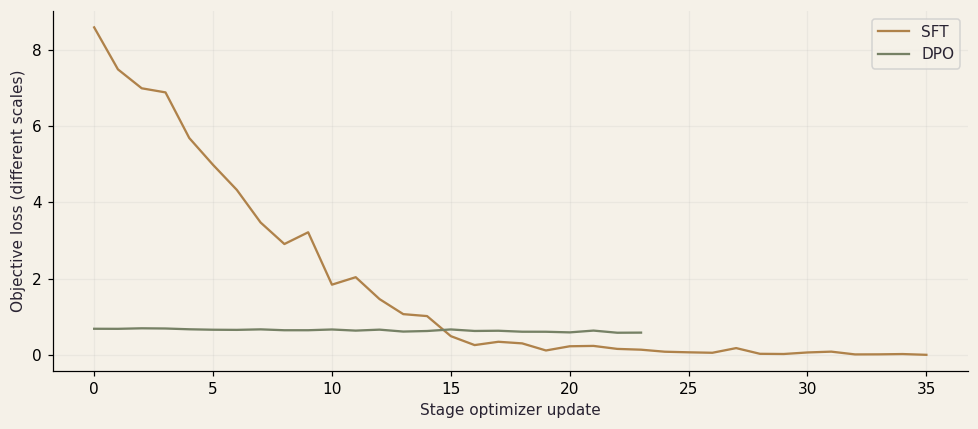

In [5]:
answers=run['examples']['DPO']; sessions=[]
for i in range(8):
    w=goal.make_workspace(i,'test'); session=goal.Session(w,4)
    for j,source in enumerate(w.sources):
        session.execute('read',j)
        if answers[2*i+j].strip().lower()=='include':
            session.execute('submit',goal.Briefing(source.value,source.source_id,w.period)); break
    sessions.append(session)
table(['Case','Generated decisions','Verified briefing'], [[s.workspace.case_id,answers[2*i:2*i+2],goal.verify(s.workspace,s.artifact)['success']] for i,s in enumerate(sessions)])
print('End-to-end success:',np.mean([goal.verify(s.workspace,s.artifact)['success'] for s in sessions]))
for label,loss in run['losses'].items(): plt.plot(loss,label=label)
plt.xlabel('Stage optimizer update'); plt.ylabel('Objective loss (different scales)'); plt.legend(); plt.tight_layout(); plt.show()

## Interpret the evidence

In the reference run, SFT fixes generated-label formatting and accuracy; DPO increases the margin without improving already-perfect held-out accuracy. Check actual generated decisions and final briefing artifacts instead of treating the optimization loss as the result.

## Change a constraint: predict first

Require exactly one source to be labeled include; abstain if the model labels both or neither. Predict the coverage/precision tradeoff.

### Worked solution

Run this after writing your prediction. Compare the changed condition with the reference condition above.

In [6]:
strict=[]
for i in range(8):
    w=goal.make_workspace(i,'test'); indices=[j for j,a in enumerate(answers[2*i:2*i+2]) if a.strip().lower()=='include']
    a=None if len(indices)!=1 else goal.Briefing(w.sources[indices[0]].value,w.sources[indices[0]].source_id,w.period)
    strict.append(goal.verify(w,a)['success'])
print('Strict end-to-end success:',np.mean(strict))
print('Abstention avoids an arbitrary tie-break but does not resolve missing evidence.')

Strict end-to-end success: 1.0
Abstention avoids an arbitrary tie-break but does not resolve missing evidence.


## What this stage contributes

A real language-model eligibility component operating on GoalLab sources. Deterministic extraction still computes values. Theory: [DPO](../../../chapters/38-direct-preference-optimization/README.md).

[Stage 08](08_one_problem_many_algorithms.ipynb) · [Stage 10](10_verifiable_reasoning_grpo.ipynb)